In [2]:
import os
import re
import sys
import argparse
import subprocess
import matplotlib
import time
import pandas as pd
import numpy as np
from itertools import groupby
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
from pylab import *
%matplotlib inline
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, confusion_matrix
import pickle
import csv
import xgboost as xgb
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from collections import defaultdict
import operator
from sklearn import svm
from sklearn.model_selection import StratifiedKFold
from Bio import SeqIO

In [3]:
#all cooking things
os.chdir("/home/pavelkrav/") # заходим в корень

root = os.getcwd() # просто корень, где будем работать
basicdir = os.path.abspath('Release/TF-ML/') # директория для общих файлов
outputdir = os.path.abspath('Release/TF-ML/outputdir') # директория для подготовки данных
train_dir = os.path.abspath('Release/TF-ML/train/') 
test_dir = os.path.abspath('Release/TF-ML/test/') 

if not os.path.exists(basicdir): # если нет result, то создаем
    os.makedirs(basicdir)
if not os.path.exists(outputdir): # если нет outputdir, то создаем
    os.makedirs(outputdir)
if not os.path.exists(train_dir): # если нет outputdir, то создаем
    os.makedirs(train_dir)
if not os.path.exists(test_dir): # если нет outputdir, то создаем
    os.makedirs(test_dir)

pwmdir_mono = os.path.abspath('/home/pavelkrav/hocomoco11/models/pwm/mono/all') # здесь лежат все PWM каждая в своей директории
pwmdir_di = os.path.abspath('/home/pavelkrav/hocomoco11/models/pwm/di/all')


files_pwm_HUMAN_mono = []
files_pwm_MOUSE_mono = []

for d in os.listdir(pwmdir_mono): # для всех директорий с PWM 
    #print(d)
    d = pwmdir_mono + "/" + d # готовим путь
    if os.path.isdir(d): # если директория по пути существует
        os.chdir(d) # заходим в нее
        #print(d)
        if d.split("_")[-1] == "HUMAN":
            files_pwm_HUMAN_mono.append([f for f in os.listdir(os.getcwd()) if os.path.splitext(f)[1] == '.pwm']) # забираем PWM
        if d.split("_")[-1] == "MOUSE":
            files_pwm_MOUSE_mono.append([f for f in os.listdir(os.getcwd()) if os.path.splitext(f)[1] == '.pwm']) # забираем PWM
    os.chdir(pwmdir_mono) # выходим

print(len(files_pwm_HUMAN_mono))
print(len(files_pwm_MOUSE_mono))


files_pwm_HUMAN_di = []
files_pwm_MOUSE_di = []

for d in os.listdir(pwmdir_di): # для всех директорий с PWM 
    #print(d)
    d = pwmdir_di + "/" + d # готовим путь
    if os.path.isdir(d): # если директория по пути существует
        os.chdir(d) # заходим в нее
        #print(d)
        if d.split("_")[-1] == "HUMAN":
            files_pwm_HUMAN_di.append([f for f in os.listdir(os.getcwd()) if os.path.splitext(f)[1] == '.dpwm']) # забираем PWM
        if d.split("_")[-1] == "MOUSE":
            files_pwm_MOUSE_di.append([f for f in os.listdir(os.getcwd()) if os.path.splitext(f)[1] == '.dpwm']) # забираем PWM
    os.chdir(pwmdir_di) # выходим

print(len(files_pwm_HUMAN_di))
print(len(files_pwm_MOUSE_di))


def remove_duplicates(l):
    return list(set(l))

print("We have {N} TF before filtration of mono".format(N=len(remove_duplicates([x[0].split("~")[0].split("_")[0] for x in files_pwm_MOUSE_mono + files_pwm_HUMAN_mono]))))
print("We have {N} TF before filtration of di".format(N=len(remove_duplicates([x[0].split("~")[0].split("_")[0] for x in files_pwm_MOUSE_di + files_pwm_HUMAN_di]))))


796
502
270
242
We have 835 TF before filtration of mono
We have 369 TF before filtration of di


In [4]:
# пишем проверку 

TF_list = []
for i in files_pwm_MOUSE_mono + files_pwm_HUMAN_mono:
    #print(i)
    experiment_id = [x.split("~")[2].split(".")[1] for x in i] 
    d = {}
    for j in experiment_id:
        if j in d.keys(): # делаем словарь из экспериментов
            d[j] += 1
        else:
            d[j] = 1
    #print(d)
    if len(d.keys()) >= 2: #Берем только те TF, в которых больше двух экспериментов
        TF_list.append(i)
          
#print(len(TF_list)) 

dict_of_names = {}
for i in TF_list:
    i = i[0].split("~")[0].split("_")[0]
    #print(i)
    if i in dict_of_names.keys():
        dict_of_names[i] += 1
    else:
        dict_of_names[i] = 1

good_names_list_mono = []  # получили лист с TF, которые встречаются у мыши и человека
for i in dict_of_names.keys():
    if dict_of_names[i] >= 2:
        good_names_list_mono.append(i)

print(good_names_list_mono[:10])


files_pwm_MOUSE_filtered = []
files_pwm_HUMAN_filtered = []

for i in files_pwm_MOUSE_mono:
    if i[0].split("~")[0].split("_")[0] in good_names_list_mono:
        files_pwm_MOUSE_filtered.append(i)

for i in files_pwm_HUMAN_mono:
    if i[0].split("~")[0].split("_")[0] in good_names_list_mono:
        files_pwm_HUMAN_filtered.append(i)


TF_list = []
for i in files_pwm_MOUSE_di + files_pwm_HUMAN_di:
    #print(i)
    experiment_id = [x.split("~")[2].split(".")[1] for x in i] 
    d = {}
    for j in experiment_id:
        if j in d.keys(): # делаем словарь из экспериментов
            d[j] += 1
        else:
            d[j] = 1
    #print(d)
    if len(d.keys()) >= 2: #Берем только те TF, в которых больше двух экспериментов
        TF_list.append(i)
          
#print(len(TF_list)) 

dict_of_names = {}
for i in TF_list:
    i = i[0].split("~")[0].split("_")[0]
    #print(i)
    if i in dict_of_names.keys():
        dict_of_names[i] += 1
    else:
        dict_of_names[i] = 1

good_names_list_di = []  # получили лист с TF, которые встречаются у мыши и человека
for i in dict_of_names.keys():
    if dict_of_names[i] >= 2:
        good_names_list_di.append(i)

print(good_names_list_di[:10])

files_pwm_MOUSE_filtered = []
files_pwm_HUMAN_filtered = []

for i in files_pwm_MOUSE_di:
    if i[0].split("~")[0].split("_")[0] in good_names_list_di:
        files_pwm_MOUSE_filtered.append(i)

for i in files_pwm_HUMAN_di:
    if i[0].split("~")[0].split("_")[0] in good_names_list_di:
        files_pwm_HUMAN_filtered.append(i)
        
good_names_list = set(good_names_list_mono) & set(good_names_list_di)

selected_short_names_list = good_names_list
selected_HUMAN = [x + "_HUMAN" for x in good_names_list]
selected_MOUSE = [x + "_MOUSE" for x in good_names_list]

print("We got {N} TF".format(N=len(selected_short_names_list)))
selected_full_names_list = selected_HUMAN + selected_MOUSE

['NKX22', 'KLF4', 'MAFG', 'STAT4', 'SPI1', 'ELK4', 'TCF7', 'DDIT3', 'PO5F1', 'TBPL1']
['KLF4', 'MAFG', 'STAT4', 'SPI1', 'TCF7', 'PO5F1', 'MYOD1', 'IRF1', 'GATA1', 'HNF4A']
We got 103 TF


In [5]:
# На этих ломается Biasaway, так как слишком мало последовательностей

selected_HUMAN.remove('NR1H3_HUMAN')
selected_MOUSE.remove('NR1H3_MOUSE')               
#selected_HUMAN.index('RUNX3_HUMAN')
selected_full_names_list = selected_HUMAN + selected_MOUSE
print("We got {N} TF".format(N=len(selected_full_names_list)))
selected_HUMAN.remove('RUNX3_HUMAN')
selected_MOUSE.remove('RUNX3_MOUSE')               
#selected_HUMAN.index('RUNX3_HUMAN')
selected_full_names_list = selected_HUMAN + selected_MOUSE
print("We got {N} TF".format(N=len(selected_full_names_list)))
selected_HUMAN.remove('SMAD2_HUMAN')
selected_MOUSE.remove('SMAD2_MOUSE')               
#selected_HUMAN.index('RUNX3_HUMAN')
selected_full_names_list = selected_HUMAN + selected_MOUSE
print("We got {N} TF".format(N=len(selected_full_names_list)))
selected_HUMAN.remove('STAT6_HUMAN')
selected_MOUSE.remove('STAT6_MOUSE')               
#selected_HUMAN.index('RUNX3_HUMAN')
selected_full_names_list = selected_HUMAN + selected_MOUSE
print("We got {N} TF".format(N=len(selected_full_names_list)))



We got 204 TF
We got 202 TF
We got 200 TF
We got 198 TF


In [6]:
selected_HUMAN.remove('STAT4_HUMAN')
selected_MOUSE.remove('STAT4_MOUSE')   

In [7]:
selected_HUMAN = ['ANDR_HUMAN',
 'AP2A_HUMAN',
 'BATF_HUMAN',
 'CEBPB_HUMAN',
 'COE1_HUMAN',
 'CTCF_HUMAN',
 'E2F4_HUMAN',
 'ERG_HUMAN',
 'ESR1_HUMAN',
 'FLI1_HUMAN',
 'GATA1_HUMAN',
 'GATA2_HUMAN',
 'GATA3_HUMAN',
 'GCR_HUMAN',
 'HNF4A_HUMAN',
 'IRF1_HUMAN',
 'IRF4_HUMAN',
 'JUND_HUMAN',
 'MAFK_HUMAN',
 'MAX_HUMAN',
 'MYC_HUMAN',
 'MYOD1_HUMAN',
 'P53_HUMAN',
 'PPARG_HUMAN',
 'PRGR_HUMAN',
 'REST_HUMAN',
 'RUNX1_HUMAN',
 'RXRA_HUMAN',
 'SOX2_HUMAN',
 'SPI1_HUMAN',
 'SRF_HUMAN',
 'STA5A_HUMAN',
 'STAT1_HUMAN',
 'STAT3_HUMAN',
 'TAL1_HUMAN',
 'TF65_HUMAN',
 'TFE2_HUMAN',
 'USF2_HUMAN']

selected_MOUSE = ['ANDR_MOUSE',
 'AP2A_MOUSE',
 'BATF_MOUSE',
 'CEBPB_MOUSE',
 'COE1_MOUSE',
 'CTCF_MOUSE',
 'E2F4_MOUSE',
 'ERG_MOUSE',
 'ESR1_MOUSE',
 'FLI1_MOUSE',
 'GATA1_MOUSE',
 'GATA2_MOUSE',
 'GATA3_MOUSE',
 'GCR_MOUSE',
 'HNF4A_MOUSE',
 'IRF1_MOUSE',
 'IRF4_MOUSE',
 'JUND_MOUSE',
 'MAFK_MOUSE',
 'MAX_MOUSE',
 'MYC_MOUSE',
 'MYOD1_MOUSE',
 'P53_MOUSE',
 'PPARG_MOUSE',
 'PRGR_MOUSE',
 'REST_MOUSE',
 'RUNX1_MOUSE',
 'RXRA_MOUSE',
 'SOX2_MOUSE',
 'SPI1_MOUSE',
 'SRF_MOUSE',
 'STA5A_MOUSE',
 'STAT1_MOUSE',
 'STAT3_MOUSE',
 'TAL1_MOUSE',
 'TF65_MOUSE',
 'TFE2_MOUSE',
 'USF2_MOUSE']

In [9]:
os.chdir("/home/pavelkrav/")

from Bio import SeqIO
import pandas as pd
import numpy as np
from statistics import mean 
from Bio.SeqUtils import GC

def Calc_GC_Average(TF, in_file_name): 
    input_file = open("Release/TF-ML/outputdir/" + TF.split("_")[0] + "/"+in_file_name+".fasta", 'r')
    GC_list = []
    for cur_record in SeqIO.parse(input_file, "fasta") :
        #count nucleotides in this record...
        gene_name = cur_record.name
        cg_percentage = GC(cur_record.seq)
        GC_list.append(cg_percentage)
    input_file.close()
    return mean(GC_list) 

 
    
df_all = pd.DataFrame(columns =['TF', 'train_pos_id_HUMAN', 'train_neg_id_HUMAN', 'test_pos_id_HUMAN', 'test_neg_id_HUMAN', 'train_pos_id_MOUSE', 'train_neg_id_MOUSE', 'test_pos_id_MOUSE', 'test_neg_id_MOUSE', 'out_HUMAN_result_H_train', 'out_HUMAN_result_H_control', 'out_MOUSE_result_M_train', 'out_MOUSE_result_M_control'])
    

for TF in ["ANDR_HUMAN", "FLI1_HUMAN", "GATA1_HUMAN", "ERG_HUMAN", "PRGR_HUMAN", "TFE2_HUMAN", "GATA3_HUMAN", "SRF_HUMAN"]: #sort(selected_HUMAN):
    #print(TF)

    train_pos_id_MOUSE = Calc_GC_Average(TF, "train_pos_id_MOUSE")
    train_neg_id_MOUSE = Calc_GC_Average(TF, "train_neg_id_MOUSE")
    train_pos_id_HUMAN = Calc_GC_Average(TF, "train_pos_id_HUMAN")
    train_neg_id_HUMAN = Calc_GC_Average(TF, "train_neg_id_HUMAN")
    test_pos_id_MOUSE = Calc_GC_Average(TF, "test_pos_id_MOUSE")
    test_neg_id_MOUSE = Calc_GC_Average(TF, "test_neg_id_MOUSE")
    test_pos_id_HUMAN = Calc_GC_Average(TF, "test_pos_id_HUMAN")
    test_neg_id_HUMAN = Calc_GC_Average(TF, "test_neg_id_HUMAN")
    out_MOUSE_result_M_train = Calc_GC_Average(TF, "out_MOUSE_result_M_train")
    out_MOUSE_result_M_control = Calc_GC_Average(TF, "out_MOUSE_result_M_control")
    out_HUMAN_result_H_train = Calc_GC_Average(TF, "out_HUMAN_result_H_train")
    out_HUMAN_result_H_control = Calc_GC_Average(TF, "out_HUMAN_result_H_control")
    

    df = pd.DataFrame([[TF, str(round(train_pos_id_HUMAN,3)), str(round(train_neg_id_HUMAN,3)), str(round(test_pos_id_HUMAN,3)), str(round(test_neg_id_HUMAN,3)), str(round(train_pos_id_MOUSE,3)), str(round(train_neg_id_MOUSE,3)), str(round(test_pos_id_MOUSE,3)), str(round(test_neg_id_MOUSE,3)), str(round(out_HUMAN_result_H_train,3)), str(round(out_HUMAN_result_H_control,3)), str(round(out_MOUSE_result_M_train,3)), str(round(out_MOUSE_result_M_control,3))]],
               columns =['TF', 'train_pos_id_HUMAN', 'train_neg_id_HUMAN', 'test_pos_id_HUMAN', 'test_neg_id_HUMAN', 'train_pos_id_MOUSE', 'train_neg_id_MOUSE', 'test_pos_id_MOUSE', 'test_neg_id_MOUSE', 'out_HUMAN_result_H_train', 'out_HUMAN_result_H_control', 'out_MOUSE_result_M_train', 'out_MOUSE_result_M_control'])

    df_all = df_all.append(df)
    print("\t".join([TF, str(round(train_pos_id_HUMAN,3)), str(round(train_neg_id_HUMAN,3)), str(round(test_pos_id_HUMAN,3)), str(round(test_neg_id_HUMAN,3)), str(round(train_pos_id_MOUSE,3)), str(round(train_neg_id_MOUSE,3)), str(round(test_pos_id_MOUSE,3)), str(round(test_neg_id_MOUSE,3)), str(round(out_HUMAN_result_H_train,3)), str(round(out_HUMAN_result_H_control,3)), str(round(out_MOUSE_result_M_train,3)), str(round(out_MOUSE_result_M_control,3))]))
    
    
df_all    
    

ANDR_HUMAN	44.151	51.566	43.581	53.538	47.932	50.486	47.756	51.155	50.288	52.36	49.213	49.618
FLI1_HUMAN	58.816	51.106	58.357	52.477	58.62	49.883	58.138	50.39	57.659	58.323	51.017	50.688
GATA1_HUMAN	48.597	51.47	48.526	52.716	50.633	50.15	49.887	50.871	51.187	51.77	49.998	50.101
ERG_HUMAN	47.035	51.106	46.542	52.477	60.493	49.883	60.248	50.39	50.899	51.438	54.739	52.091
PRGR_HUMAN	49.076	51.566	48.56	53.538	46.572	50.486	46.864	51.155	48.962	48.551	46.669	48.199
TFE2_HUMAN	59.315	49.222	57.573	49.855	54.339	49.586	54.336	49.948	54.182	54.679	50.217	50.391
GATA3_HUMAN	43.48	51.47	43.961	52.716	48.098	50.15	47.392	50.871	49.275	49.08	49.946	50.208
SRF_HUMAN	54.871	50.776	54.819	52.166	57.284	50.092	56.3	50.682	50.784	52.499	56.497	55.17


,TF,train_pos_id_HUMAN,train_neg_id_HUMAN,test_pos_id_HUMAN,test_neg_id_HUMAN,train_pos_id_MOUSE,train_neg_id_MOUSE,test_pos_id_MOUSE,test_neg_id_MOUSE,out_HUMAN_result_H_train,out_HUMAN_result_H_control,out_MOUSE_result_M_train,out_MOUSE_result_M_control
0,ANDR_HUMAN,44.151,51.566,43.581,53.538,47.932,50.486,47.756,51.155,50.288,52.36,49.213,49.618
0,FLI1_HUMAN,58.816,51.106,58.357,52.477,58.62,49.883,58.138,50.39,57.659,58.323,51.017,50.688
0,GATA1_HUMAN,48.597,51.47,48.526,52.716,50.633,50.15,49.887,50.871,51.187,51.77,49.998,50.101
0,ERG_HUMAN,47.035,51.106,46.542,52.477,60.493,49.883,60.248,50.39,50.899,51.438,54.739,52.091
0,PRGR_HUMAN,49.076,51.566,48.56,53.538,46.572,50.486,46.864,51.155,48.962,48.551,46.669,48.199
0,TFE2_HUMAN,59.315,49.222,57.573,49.855,54.339,49.586,54.336,49.948,54.182,54.679,50.217,50.391
0,GATA3_HUMAN,43.48,51.47,43.961,52.716,48.098,50.15,47.392,50.871,49.275,49.08,49.946,50.208
0,SRF_HUMAN,54.871,50.776,54.819,52.166,57.284,50.092,56.3,50.682,50.784,52.499,56.497,55.17


In [ ]:
stubnames=['train_pos_id_HUMAN', 'train_neg_id_HUMAN', 'test_pos_id_HUMAN', 'test_neg_id_HUMAN', 'train_pos_id_MOUSE', 'train_neg_id_MOUSE', 'test_pos_id_MOUSE', 'test_neg_id_MOUSE', 'out_HUMAN_result_H_train', 'out_HUMAN_result_H_control', 'out_MOUSE_result_M_train', 'out_MOUSE_result_M_control']

df_all_melt = pd.melt(df_all, id_vars=['TF'], value_vars=stubnames)
df_all_melt["value"] = [float(x) for x in df_all_melt["value"]]

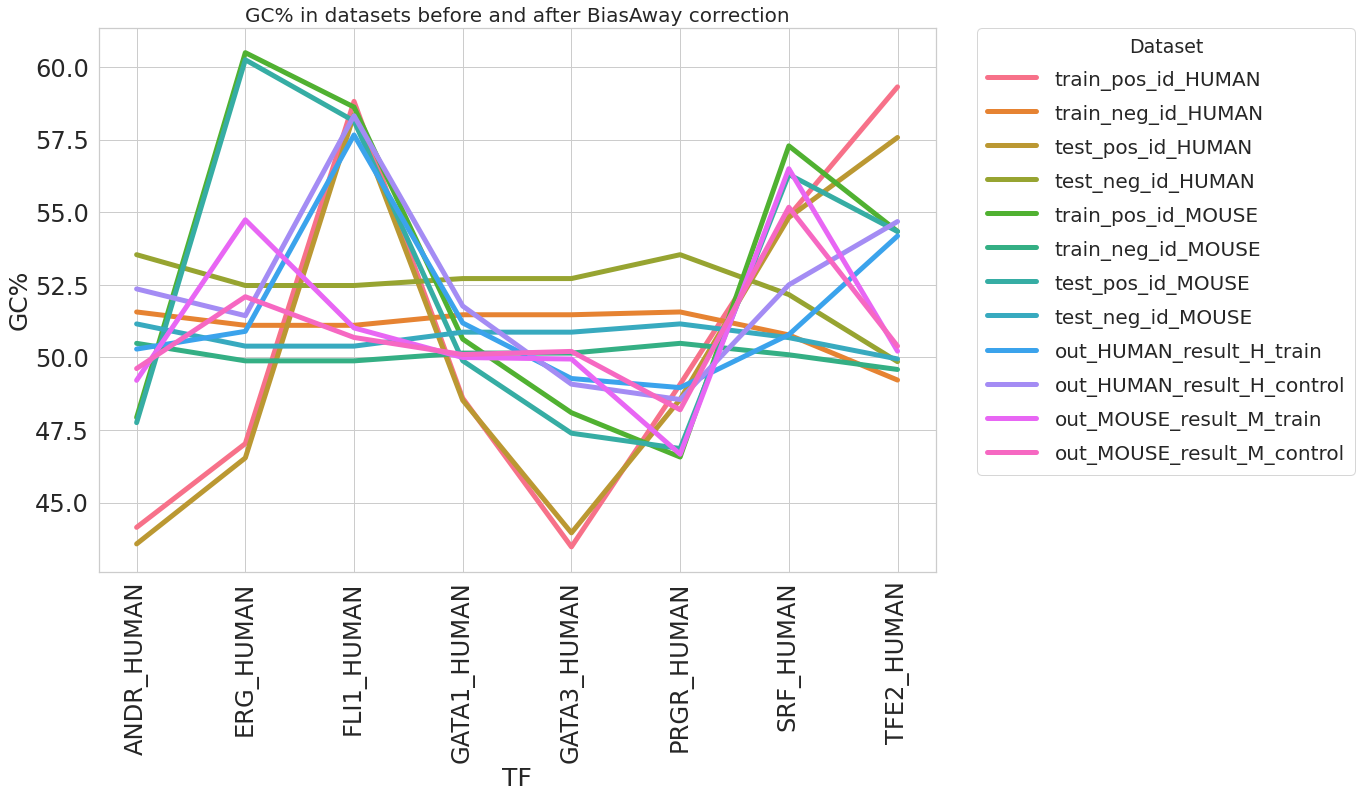

In [12]:
import matplotlib.pyplot as plt

sns.set(font_scale=2.2, style="ticks", font="Lato")
sns.set_style({"xtick.direction": "in","ytick.direction": "in"})
matplotlib.rcParams['font.weight'] = "medium"
matplotlib.rcParams['axes.labelweight'] = 'medium'
matplotlib.rcParams['figure.titleweight'] = 'medium'
matplotlib.rcParams['axes.titleweight'] = 'medium'
matplotlib.rcParams['figure.figsize'] = 15, 10
sns.set_style("whitegrid")
fig = plt.figure()



ax = sns.lineplot(
    data=df_all_melt,
    x="TF", y="value", hue="variable",
    markers=True, dashes=False,  linewidth = 5,  
    legend=False
)


plt.xlabel('TF', fontsize=25)
plt.ylabel('GC%', fontsize=25)
plt.title('GC% in datasets before and after BiasAway correction', fontsize=20)
plt.xticks(rotation=90)
legend = plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., title="Dataset", labels=stubnames)
legend.get_title().set_fontsize('19') #legend 'Title' fontsize
plt.setp(plt.gca().get_legend().get_texts(), fontsize='20') #legend 'list' fontsize

plt.show()

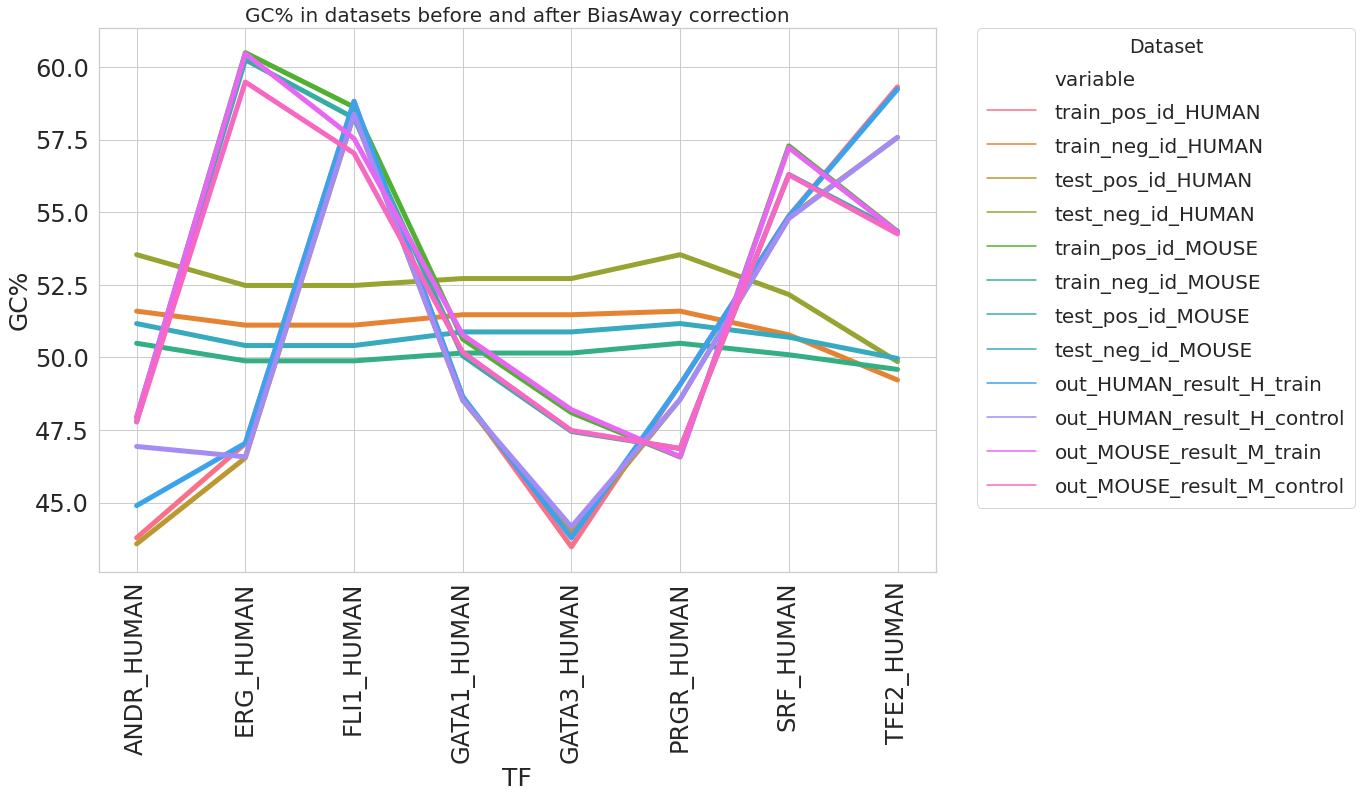

In [89]:
import matplotlib.pyplot as plt

sns.set(font_scale=2.2, style="ticks", font="Lato")
sns.set_style({"xtick.direction": "in","ytick.direction": "in"})
matplotlib.rcParams['font.weight'] = "medium"
matplotlib.rcParams['axes.labelweight'] = 'medium'
matplotlib.rcParams['figure.titleweight'] = 'medium'
matplotlib.rcParams['axes.titleweight'] = 'medium'
matplotlib.rcParams['figure.figsize'] = 15, 10
sns.set_style("whitegrid")
fig = plt.figure()



ax = sns.lineplot(
    data=df_all_melt,
    x="TF", y="value", hue="variable",
    markers=True, dashes=False,  linewidth = 5
)


plt.xlabel('TF', fontsize=25)
plt.ylabel('GC%', fontsize=25)
plt.title('GC% in datasets before and after BiasAway correction', fontsize=20)
plt.xticks(rotation=90)
legend = plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., title="Dataset")
legend.get_title().set_fontsize('19') #legend 'Title' fontsize
plt.setp(plt.gca().get_legend().get_texts(), fontsize='20') #legend 'list' fontsize

plt.show()